In [1]:
!pip install shap lime matplotlib pandas scikit-learn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 376.7 kB/s eta 0:00:25
   -- ------------------------------------- 0.5/9.9 MB 376.7 kB/s eta 0:00:25
   -- ------------------------------------- 0.5/9.9 MB 376.7 kB/s eta 0:00:25
   -- ------------------------------------- 0.5/9.9 MB 376.7 kB/s eta 0:00:25
   -- -------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
checkpoint = torch.load("model.pth")

print(type(checkpoint))


<class 'collections.OrderedDict'>


In [7]:
from torchvision import models
import torch.nn as nn
import torch


# Create ResNet18
model = models.resnet18()


# Change final layer for 10 classes
model.fc = nn.Linear(512, 10)


# Load your trained weights
model.load_state_dict(torch.load("model.pth"))


# Evaluation mode
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

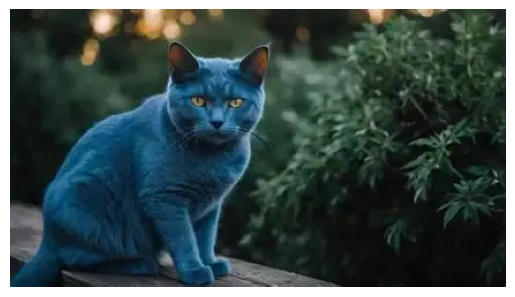

In [9]:
from PIL import Image
import matplotlib.pyplot as plt


img = Image.open("test_images/OIP (4).webp")


plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
import torchvision.transforms as transforms


transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


image_tensor = transform(img)


image_tensor = image_tensor.unsqueeze(0)


print(image_tensor.shape)

torch.Size([1, 3, 224, 224])


In [11]:
with torch.no_grad():

    output = model(image_tensor)


prediction = torch.argmax(output, dim=1)


print("Predicted class number:", prediction.item())

Predicted class number: 3


In [12]:
classes = [
    "bird",
    "bus",
    "car",
    "cat",
    "dog",
    "elephant",
    "horse",
    "lion",
    "tiger",
    "truck"
]


predicted_class = classes[prediction.item()]


print("Predicted class:", predicted_class)

Predicted class: cat
